In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from environment.scenario import MarkovYieldCurveGenerator, DepositBetaLiabilityGenerator
from models.utils import build_state
from environment.config import bond_configs, markov_config, T
from models.source.pnncritic_vec import HybridActor, ValueCritic, train_cmdp_alm, evaluate_cmdp_alm

os.makedirs("saved_models", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


In [2]:
# Dimensions setup
K = len(bond_configs)
BOND_MATURITIES = [cfg["maturity_months"] for cfg in bond_configs]
MAX_MATURITY = int(max(BOND_MATURITIES))

_yields_sample = MarkovYieldCurveGenerator.generate(T, seed=0)
_liabilities_sample = DepositBetaLiabilityGenerator.generate(_yields_sample, noise_std=0.0, seed=0)

y_dim = _yields_sample.shape[-1]
l_dim = _liabilities_sample.shape[-1]

# Accurate state dimension calculation based on your build_state return
STATE_DIM = 1 + MAX_MATURITY + y_dim + l_dim 
ACTION_DIM = K + 1

print(f"STATE_DIM  = {STATE_DIM}")
print(f"ACTION_DIM = {ACTION_DIM} (bonds ({K}) + cash (1))")
print(f"MAX_MATURITY = {MAX_MATURITY} months")

# Initialize models
actor = HybridActor(state_dim=STATE_DIM, action_dim=ACTION_DIM, hidden_dim=64, T=T).to(device)
critic = ValueCritic(state_dim=STATE_DIM, hidden_dim=64, T=T).to(device)

print(f"Actor parameters:  {sum(p.numel() for p in actor.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in critic.parameters()):,}")

STATE_DIM  = 29
ACTION_DIM = 6 (bonds (5) + cash (1))
MAX_MATURITY = 24 months
Actor parameters:  6,918
Critic parameters: 6,209


In [3]:
print("Starting Hybrid Training Loop...")

trained_actor, trained_critic, history = train_cmdp_alm(
    actor=actor,
    critic=critic,
    markov_config=markov_config,
    epochs=600,
    batch_size=512,
    lr=0.003944310093900399,
    critic_lr=0.0014406438064688248,
    lmbda=0,
    ent_coef_init=0.01,
    ent_coef_final=0.0005,
    train_seed_offset=6_000_000
)

Starting Hybrid Training Loop...
Epoch    0 | ActLoss:   3.6611 | VLoss: 0.5173 | NAV: -18.06 | Ent: -1.688 | EntCoef: 0.01000 | Lambda: 0.000 | HardPen: 700.0000
Epoch   10 | ActLoss:   1.2753 | VLoss: 0.0692 | NAV: -10.53 | Ent: -2.299 | EntCoef: 0.00980 | Lambda: 0.000 | HardPen: 697.2656
Epoch   20 | ActLoss:  -0.7225 | VLoss: 0.0390 | NAV: 20.08 | Ent: -3.269 | EntCoef: 0.00960 | Lambda: 0.000 | HardPen: 668.5547
Epoch   30 | ActLoss:  -0.0163 | VLoss: 0.0105 | NAV: -8.14 | Ent: -2.034 | EntCoef: 0.00941 | Lambda: 0.000 | HardPen: 691.7969
Epoch   40 | ActLoss:   0.3661 | VLoss: 0.0137 | NAV: -18.00 | Ent: -1.842 | EntCoef: 0.00921 | Lambda: 0.000 | HardPen: 697.2656
Epoch   50 | ActLoss:  -0.0388 | VLoss: 0.0105 | NAV: -11.13 | Ent: -2.005 | EntCoef: 0.00901 | Lambda: 0.000 | HardPen: 692.3828
Epoch   60 | ActLoss:  -0.0136 | VLoss: 0.0087 | NAV: -16.29 | Ent: -1.922 | EntCoef: 0.00881 | Lambda: 0.000 | HardPen: 697.2656
Epoch   70 | ActLoss:   0.1834 | VLoss: 0.0082 | NAV: -29.9

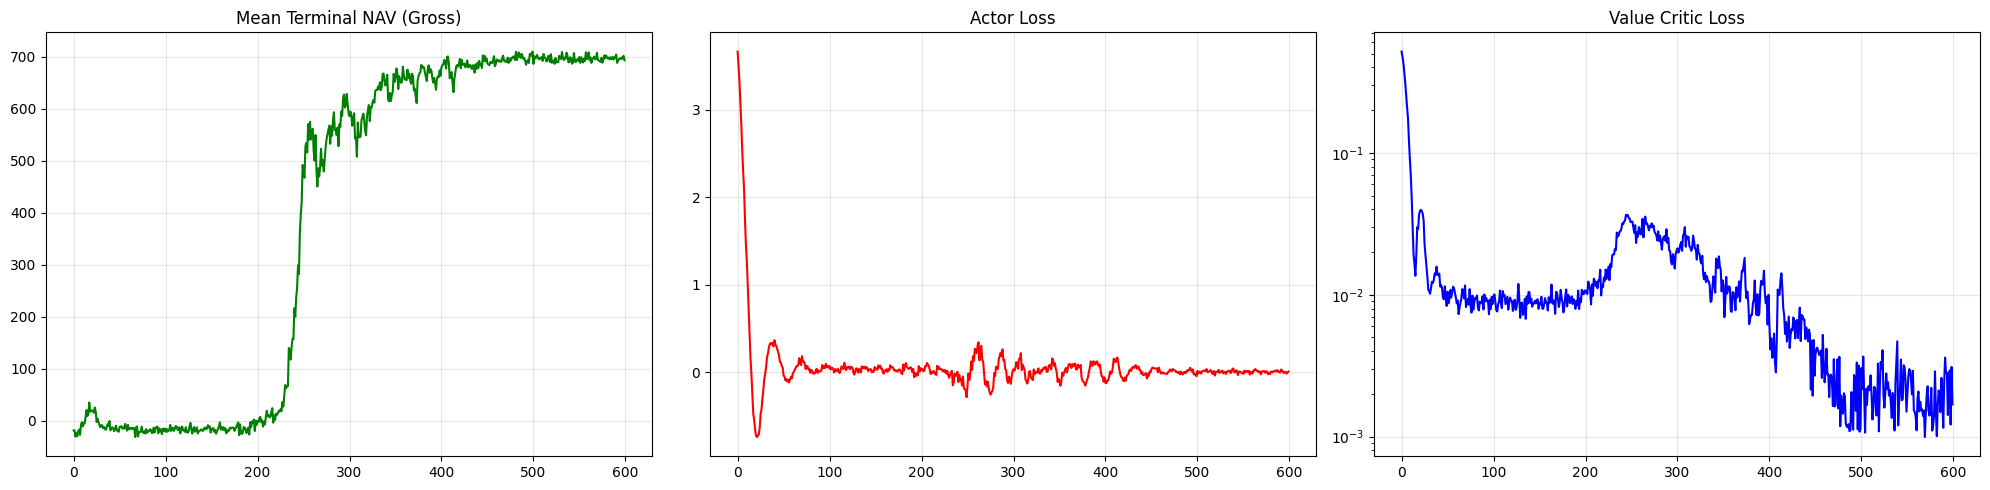

In [4]:
# Diagnostics Plots
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].plot(history["epoch"], history["mean_nav"], color='green')
axs[0].set_title("Mean Terminal NAV (Gross)")
axs[0].grid(True, alpha=0.3)

axs[1].plot(history["epoch"], history["actor_loss"], color='red')
axs[1].set_title("Actor Loss")
axs[1].grid(True, alpha=0.3)

axs[2].plot(history["epoch"], history["v_loss"], color='blue')
axs[2].set_title("Value Critic Loss")
axs[2].set_yscale('log')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
from models.source.pnncritic_vec import evaluate_pnncritic_agent

evaluate_pnncritic_agent(trained_actor, markov_config, K, seed=0, verbose=True);

Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 237.42
  LCR: 14.7876  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  ---------------------------------------------------------------------------------

In [ ]:
# Deterministic Step Test (t=0)
trained_actor.eval()

initial_cash = markov_config["W0"]
i0, i1 = markov_config["i0_init"], markov_config["i1_init"]
beta_0 = markov_config["BETA0_GRID"][i0]
beta_1 = markov_config["BETA1_GRID"][i1]
beta_2 = markov_config["BETA2"]

betas_t = torch.tensor([[beta_0, beta_1, beta_2]], dtype=torch.float32, device=device)
liab_0 = markov_config["L_ALL"][i0, i1]
liab_t = torch.tensor([[liab_0]], dtype=torch.float32, device=device)
cash = torch.tensor([[initial_cash]], dtype=torch.float32, device=device)
future_cash = torch.zeros((1, MAX_MATURITY), dtype=torch.float32, device=device)

state = build_state(cash , future_cash , betas_t, liab_t )
prev_action = torch.zeros((1, ACTION_DIM), dtype=torch.float32, device=device)

with torch.no_grad():
    final_action, _, _= trained_actor(0, state, prev_action, deterministic=True)

print("\nChosen Allocation at t=0:")
for idx in range(K):
    print(f"Bond {BOND_MATURITIES[idx]}M: {final_action[0, idx].item()*100:.2f}%")
print(f"Cash:    {final_action[0, -1].item()*100:.2f}%")

# Full Out-of-Sample Evaluation
print("\nStarting robust out-of-sample evaluation...")
eval_metrics, eval_raw_results = evaluate_cmdp_alm(
    actor=trained_actor,
    critic=trained_critic,
    markov_config=markov_config,
    eval_episodes=2000,
    device=device,
    seed_offset=10_000_000
)




Chosen Allocation at t=0:
Bond 1M: 33.09%
Bond 3M: 33.83%
Bond 6M: 17.59%
Bond 12M: 1.62%
Bond 24M: 1.61%
Cash:    12.25%

Starting robust out-of-sample evaluation...

=== Evaluation Results ===
Mean NAV:       697.47 ± 103.66
Median NAV:     695.92
Min / Max NAV:  389.04 / 1041.67
VaR  (5%):      532.10
CVaR (5%):      487.64
Mean Penalty:   0.0000
Violation Rate: 0.0000%
Default Rate:   0.0000%


In [9]:
# Deterministic Step Test (t=0)
trained_actor.eval()

initial_cash = markov_config["W0"]
i0, i1 = markov_config["i0_init"], markov_config["i1_init"]
beta_0 = markov_config["BETA0_GRID"][i0]
beta_1 = markov_config["BETA1_GRID"][i1]
beta_2 = markov_config["BETA2"]

betas_t = torch.tensor([[beta_0, beta_1, beta_2]], dtype=torch.float32, device=device)
liab_0 = markov_config["L_ALL"][i0, i1]
liab_t = torch.tensor([[liab_0]], dtype=torch.float32, device=device)
cash = torch.tensor([[initial_cash]], dtype=torch.float32, device=device)
future_cash = torch.zeros((1, MAX_MATURITY), dtype=torch.float32, device=device)

state = build_state(cash , future_cash , betas_t, liab_t )
prev_action = torch.zeros((1, ACTION_DIM), dtype=torch.float32, device=device)

with torch.no_grad():
    final_action, _, _= trained_actor(0, state, prev_action, deterministic=True)

print("\nChosen Allocation at t=0:")
for idx in range(K):
    print(f"Bond {BOND_MATURITIES[idx]}M: {final_action[0, idx].item()*100:.2f}%")
print(f"Cash:    {final_action[0, -1].item()*100:.2f}%")

# Full Out-of-Sample Evaluation
print("\nStarting robust out-of-sample evaluation...")
eval_metrics, eval_raw_results = evaluate_cmdp_alm(
    actor=trained_actor,
    critic=trained_critic,
    markov_config=markov_config,
    eval_episodes=100_000,
    device=device,
    seed_offset=10_000_000
)




Chosen Allocation at t=0:
Bond 1M: 33.09%
Bond 3M: 33.83%
Bond 6M: 17.59%
Bond 12M: 1.62%
Bond 24M: 1.61%
Cash:    12.25%

Starting robust out-of-sample evaluation...

=== Evaluation Results ===
Mean NAV:       700.07 ± 106.87
Median NAV:     700.13
Min / Max NAV:  -437.01 / 1157.66
VaR  (5%):      524.41
CVaR (5%):      481.05
Mean Penalty:   0.0630
Violation Rate: 0.0090%
Default Rate:   0.0090%


In [8]:
# Save Unified Checkpoint
checkpoint = {
    "actor_state_dict": trained_actor.state_dict(),
    "critic_state_dict": trained_critic.state_dict(),
    "state_dim": STATE_DIM,
    "action_dim": ACTION_DIM,
    "T": T,
    "hidden_dim": 64,
}

save_path = "saved_models/pnncritic_T1.pth" if T == 1 else "saved_models/pnncritic.pth"
print(f"\nSaving unified Hybrid model to {save_path}")
torch.save(checkpoint, save_path)


Saving unified Hybrid model to saved_models/pnncritic.pth
